# 01 — Understanding the CAMUS Dataset

## Learning objectives

By the end of this notebook, I should be able to:

1. Explain how patients, cardiac views, cardiac phases, images, and masks are related.
2. Load one CAMUS ultrasound image and its corresponding segmentation mask.
3. Inspect image shape, data type, pixel spacing, intensity range, and mask labels.
4. Explain what one training sample represents in a semantic segmentation task.
5. Identify data-quality and data-splitting checks that prevent invalid experiments.

## Working method

Each section follows the same cycle:

1. State the question that the code should answer.
2. Write and run the smallest useful code cell.
3. Interpret the output in plain language.
4. Record a conclusion before moving to the next section.

## Step 1 — Verify the notebook environment

Before reading data, verify the notebook's current working directory and confirm that NiBabel is available in the selected kernel. Relative file paths are resolved from the current working directory, so an incorrect directory can make valid project paths appear to be missing.

**Coding task:** Create a code cell below that:

- imports `Path` from `pathlib`;
- imports `nibabel` using the alias `nib`;
- prints the current working directory;
- prints the installed NiBabel version.


In [2]:
from pathlib import Path
import nibabel as nib

print("Current working directory:", Path.cwd())
print("Nibabel version:", nib.__version__)


Current working directory: /home/felix/Workspace/projects/dl-segmentation-camus/notebooks
Nibabel version: 5.4.2


### Step 1 conclusion

The notebook kernel is using an environment that provides NiBabel 5.4.2. Its current working directory is the project's `notebooks/` directory, not the project root. Therefore, paths such as `data/raw/camus` would be resolved from the wrong location if they were used directly.

## Step 2 — Define explicit project and data paths

The project root is the parent of the current `notebooks/` directory. Building paths from that known relationship is clearer and more reproducible than hard-coding an absolute path tied to one computer.

`pathlib.Path` uses the `/` operator to join path components. In this context, `/` constructs a new path; it is not numeric division.

Use uppercase names for these values because they act as notebook-level configuration constants.

**Coding task:** Create a code cell below that:

1. stores the current working directory in `NOTEBOOK_DIR`;
2. derives `PROJECT_ROOT` from the parent of `NOTEBOOK_DIR`;
3. constructs `DATA_DIR` for the project's top-level `data/` directory;
4. constructs `CAMUS_ROOT` for `data/raw/camus`;
5. prints all four paths;
6. prints whether `CAMUS_ROOT` is an existing directory.


In [3]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_ROOT / "data"
CAMUS_ROOT = DATA_DIR / "raw" / "camus"

print("Notebook directory:", NOTEBOOK_DIR)
print("Project root directory:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("CAMUS directory:", CAMUS_ROOT)
print("CAMUS directory exists:", CAMUS_ROOT.is_dir())

Notebook directory: /home/felix/Workspace/projects/dl-segmentation-camus/notebooks
Project root directory: /home/felix/Workspace/projects/dl-segmentation-camus
Data directory: /home/felix/Workspace/projects/dl-segmentation-camus/data
CAMUS directory: /home/felix/Workspace/projects/dl-segmentation-camus/data/raw/camus
CAMUS directory exists: True


### Step 2 conclusion

The notebook now derives every project path from its known working directory. `CAMUS_ROOT` points to the intended `data/raw/camus` directory, and `is_dir()` confirms that the directory exists. This avoids machine-specific absolute paths while still failing clearly if the project structure changes.

## Step 3 — Identify and count patient directories

CAMUS is organized primarily by patient. Each directory named `patientXXXX` represents one patient and contains multiple views, phases, images, masks, and metadata files. A patient is therefore the independent subject unit; an individual image is not an independent patient.

`Path.glob("patient*")` finds entries whose names begin with `patient`. Filtering with `is_dir()` prevents a similarly named file from being counted as a patient. `sorted()` gives a deterministic order, which makes inspection and later data processing reproducible.

**Coding task:** Create a code cell below that:

1. finds entries under `CAMUS_ROOT` whose names begin with `patient`;
2. keeps only directories;
3. sorts the resulting paths and stores them in `patient_dirs`;
4. prints the number of patient directories;
5. prints the names of the first three and last three patients.

The official CAMUS dataset contains 500 patients. The purpose of this check is to verify the local dataset rather than simply assume that the download is complete.


In [4]:
patient_dirs = sorted(
    path
    for path in CAMUS_ROOT.glob("patient*")
    if path.is_dir()
)

print("Number of patient directories:", len(patient_dirs))
print("First three patients:", [path.name for path in patient_dirs[:3]])
print("Last three patients:", [path.name for path in patient_dirs[-3:]])

Number of patient directories: 500
First three patients: ['patient0001', 'patient0002', 'patient0003']
Last three patients: ['patient0498', 'patient0499', 'patient0500']


### Step 3 conclusion

The local dataset contains 500 patient directories, from `patient0001` through `patient0500`. This matches the expected CAMUS patient count. It verifies the top-level patient inventory, but it does not yet prove that every patient directory contains the required files.

## Step 4 — Inspect one patient directory

Before writing a dataset-wide validator, inspect one representative patient. This reveals the naming convention and the relationship between metadata, cardiac views, cardiac phases, ultrasound images, and segmentation masks.

`patient_dirs[0]` selects the first path from the sorted patient list. `Path.iterdir()` iterates over the direct children of that directory. Filtering with `is_file()` excludes any nested directories, and sorting makes the displayed order deterministic.

The purpose of this step is observation: list the files first, then interpret their names. Do not build filename assumptions into a data loader before verifying the actual data layout.


In [5]:
sample_patient_dir = patient_dirs[0]
sample_files = sorted(
    path
    for path in sample_patient_dir.iterdir()
    if path.is_file()
)

print("Selected patient:", sample_patient_dir.name)
print("Number of files:", len(sample_files))
print("Files:")

for path in sample_files:
    print(" -", path.name)

Selected patient: patient0001
Number of files: 15
Files:
 - Info_2CH.cfg
 - Info_4CH.cfg
 - MANDATORY_CITATION.md
 - patient0001_2CH_ED.nii.gz
 - patient0001_2CH_ED_gt.nii.gz
 - patient0001_2CH_ES.nii.gz
 - patient0001_2CH_ES_gt.nii.gz
 - patient0001_2CH_half_sequence.nii.gz
 - patient0001_2CH_half_sequence_gt.nii.gz
 - patient0001_4CH_ED.nii.gz
 - patient0001_4CH_ED_gt.nii.gz
 - patient0001_4CH_ES.nii.gz
 - patient0001_4CH_ES_gt.nii.gz
 - patient0001_4CH_half_sequence.nii.gz
 - patient0001_4CH_half_sequence_gt.nii.gz


### Step 4 conclusion

`patient0001` contains 15 files:

- two view-specific configuration files;
- one mandatory citation notice;
- twelve NIfTI files: two views × three data variants × two roles.

The filename components have the following meanings:

| Component | Meaning |
|---|---|
| `2CH` | Apical two-chamber view |
| `4CH` | Apical four-chamber view |
| `ED` | End-diastole, when the left ventricle is typically at its largest |
| `ES` | End-systole, when the left ventricle is typically at its smallest |
| `_gt` | Ground-truth segmentation annotation |
| `half_sequence` | A multi-frame sequence variant; its exact dimensions and label content must be verified from the data |
| `.nii.gz` | A gzip-compressed NIfTI medical-image file |

The `MANDATORY_CITATION.md` file is part of the dataset usage requirements, not a training sample. The final repository and project report must preserve the required CAMUS citation.

## Step 5 — Read the view metadata as raw text

`Info_2CH.cfg` and `Info_4CH.cfg` contain metadata for the two cardiac views. Read the original text before writing a parser so that the parser is based on observed syntax rather than assumptions.

`Path.read_text()` reads a text file into a Python string. Printing the two files separately makes differences between views visible.


In [6]:
info_2ch_path = sample_patient_dir / "Info_2CH.cfg"
info_4ch_path = sample_patient_dir / "Info_4CH.cfg"

print("2CH metadata:")
print(info_2ch_path.read_text())

print("4CH metadata:")
print(info_4ch_path.read_text())

2CH metadata:
ED: 1
ES: 18
NbFrame: 18
Sex: F
Age: 56
ImageQuality: Good
EF: 54
FrameRate: 48.4

4CH metadata:
ED: 1
ES: 20
NbFrame: 20
Sex: F
Age: 56
ImageQuality: Good
EF: 54
FrameRate: 48.4



### Step 5 conclusion

The configuration files use one `key: value` pair per line. For `patient0001`, the 2CH and 4CH acquisitions have different end-systolic frame numbers and different frame counts. View-specific frame indices must therefore be read from the corresponding configuration file rather than copied between views.

| Field | Meaning | Example |
|---|---|---|
| `ED` | End-diastolic frame number | `1` |
| `ES` | End-systolic frame number | `18` or `20` |
| `NbFrame` | Number of frames in the view sequence | `18` or `20` |
| `Sex` | Recorded patient sex | `F` |
| `Age` | Patient age in years | `56` |
| `ImageQuality` | Categorical image-quality assessment | `Good` |
| `EF` | Left-ventricular ejection fraction, expressed as a percentage | `54` |
| `FrameRate` | Acquisition rate in frames per second | `48.4` |

The frame numbers in the configuration appear in human-oriented numbering. Python arrays use zero-based indices, but no conversion should be made until the sequence dimensions have been inspected and the numbering convention has been verified.

## Step 6 — Parse configuration text into a dictionary

A Python dictionary stores key-value pairs. Parsing the file into a dictionary allows code to request a field by name, such as `config["ED"]`, instead of depending on line positions.

This first parser deliberately preserves every value as text. Converting fields to integers or floating-point numbers is a separate validation step. Keeping those operations separate makes incorrect assumptions easier to detect.


In [7]:
def read_config(path):
    config = {}

    for line in path.read_text().splitlines():
        if not line.strip():
            continue

        key, value = line.split(":", maxsplit=1)
        config[key.strip()] = value.strip()

    return config


config_2ch = read_config(info_2ch_path)
config_4ch = read_config(info_4ch_path)

print("Parsed 2CH configuration:", config_2ch)
print("Parsed 4CH configuration:", config_4ch)
print("Stored type of 2CH ED:", type(config_2ch["ED"]).__name__)

Parsed 2CH configuration: {'ED': '1', 'ES': '18', 'NbFrame': '18', 'Sex': 'F', 'Age': '56', 'ImageQuality': 'Good', 'EF': '54', 'FrameRate': '48.4'}
Parsed 4CH configuration: {'ED': '1', 'ES': '20', 'NbFrame': '20', 'Sex': 'F', 'Age': '56', 'ImageQuality': 'Good', 'EF': '54', 'FrameRate': '48.4'}
Stored type of 2CH ED: str


### Step 6 conclusion

The configuration text has been parsed into dictionaries, but every value is still a string. Field names provide structure; field types provide usable meaning. Numeric validation must happen after explicit conversion.

## Step 7 — Convert metadata to semantic types and validate frame ranges

`ED`, `ES`, `NbFrame`, `Age`, and `EF` are stored as integers. `FrameRate` is stored as a floating-point number. `Sex` and `ImageQuality` remain strings. The conversion function below applies these rules consistently to both views.

The frame checks verify that ED and ES fall within `1..NbFrame`. This is consistent with one-based frame numbering in the configuration; conversion to zero-based NumPy indices will only be needed when indexing a sequence array.


In [8]:
INTEGER_FIELDS = {"ED", "ES", "NbFrame", "Age", "EF"}
FLOAT_FIELDS = {"FrameRate"}


def convert_config_types(config):
    typed_config = {}

    for key, value in config.items():
        if key in INTEGER_FIELDS:
            typed_config[key] = int(value)
        elif key in FLOAT_FIELDS:
            typed_config[key] = float(value)
        else:
            typed_config[key] = value

    return typed_config


typed_config_2ch = convert_config_types(config_2ch)
typed_config_4ch = convert_config_types(config_4ch)

for view_name, config in [("2CH", typed_config_2ch), ("4CH", typed_config_4ch)]:
    assert 1 <= config["ED"] <= config["NbFrame"], f"{view_name}: ED is out of range"
    assert 1 <= config["ES"] <= config["NbFrame"], f"{view_name}: ES is out of range"

print("Typed 2CH configuration:", typed_config_2ch)
print("2CH ED type:", type(typed_config_2ch["ED"]).__name__)
print("2CH FrameRate type:", type(typed_config_2ch["FrameRate"]).__name__)
print("Frame-range validation: passed")

Typed 2CH configuration: {'ED': 1, 'ES': 18, 'NbFrame': 18, 'Sex': 'F', 'Age': 56, 'ImageQuality': 'Good', 'EF': 54, 'FrameRate': 48.4}
2CH ED type: int
2CH FrameRate type: float
Frame-range validation: passed


## Step 8 — Load one image-mask pair

One supervised segmentation sample consists of an input ultrasound image and its spatially aligned ground-truth mask. Here the sample is the 2CH end-diastolic frame from `patient0001`.

`nib.load()` creates a NIfTI image object containing a header, an affine transform, and a lazy data proxy. `np.asarray(nifti_image.dataobj)` materializes the stored array while preserving its represented data type, unlike `get_fdata()`, which defaults to `float64`.

A valid image-mask pair should have matching shapes and matching affine transforms. Shape alignment matches array locations; affine alignment matches their physical coordinate systems.


In [9]:
import numpy as np

patient_id = sample_patient_dir.name
image_path = sample_patient_dir / f"{patient_id}_2CH_ED.nii.gz"
mask_path = sample_patient_dir / f"{patient_id}_2CH_ED_gt.nii.gz"

image_nii = nib.load(image_path)
mask_nii = nib.load(mask_path)
image = np.asarray(image_nii.dataobj)
mask = np.asarray(mask_nii.dataobj)

print("Image path:", image_path.name)
print("Mask path:", mask_path.name)
print("Image shape / dtype:", image.shape, image.dtype)
print("Mask shape / dtype:", mask.shape, mask.dtype)
print("Pixel spacing:", image_nii.header.get_zooms())
print("Spatial units:", image_nii.header.get_xyzt_units()[0])
print("Image intensity range:", float(image.min()), float(image.max()))
print("Mask labels:", np.unique(mask).tolist())
print("Shapes match:", image.shape == mask.shape)
print("Affines match:", np.allclose(image_nii.affine, mask_nii.affine))

Image path: patient0001_2CH_ED.nii.gz
Mask path: patient0001_2CH_ED_gt.nii.gz
Image shape / dtype: (549, 389) float32
Mask shape / dtype: (549, 389) float32
Pixel spacing: (np.float32(0.308), np.float32(0.308))
Spatial units: mm
Image intensity range: 0.0 255.0
Mask labels: [0.0, 1.0, 2.0, 3.0]
Shapes match: True
Affines match: True


In [10]:
print("Image array:")
print(image)
print("\nMask array:")
print(mask)

Image array:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

Mask array:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


## Step 9 — Visualize the image and mask

`image` contains ultrasound intensities. `mask` contains class IDs. Display them side by side to see the model input and its expected output.

`.T` is used only to show both arrays in the expected orientation. The mask colors distinguish its label values; their anatomical meanings come next.


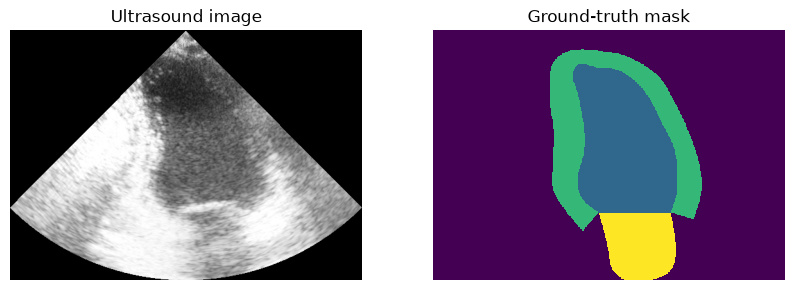

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(image.T, cmap="gray")
axes[0].set_title("Ultrasound image")

axes[1].imshow(mask.T, cmap="viridis", interpolation="nearest")
axes[1].set_title("Ground-truth mask")

for axis in axes:
    axis.axis("off")
plt.show()

## Step 10 — Interpret the mask labels

Each mask pixel is a class ID, not an intensity value. CAMUS uses the following encoding:

| ID | Structure | Meaning |
|---:|---|---|
| 0 | Background | Pixels outside the annotated structures |
| 1 | Left ventricular cavity | The blood-filled region inside the LV endocardial contour |
| 2 | Myocardium | The muscular wall between the LV endocardial and epicardial contours |
| 3 | Left atrium | The atrial region above the mitral valve plane |

The code below isolates each foreground class. `mask == label_id` produces `True` only where a pixel belongs to that class. This is a visualization step and does not change `mask`.

CAMUS reference: [Leclerc et al., IEEE TMI 2019](https://doi.org/10.1109/TMI.2019.2900516).


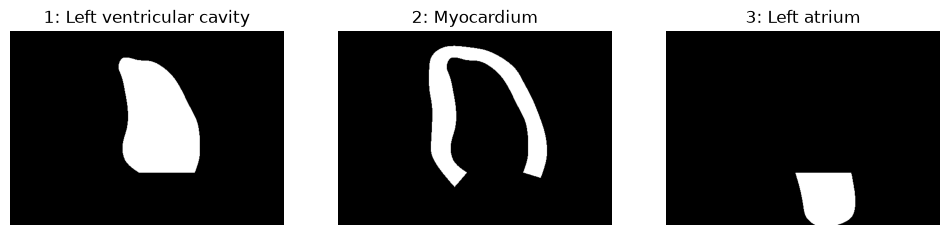

In [12]:
label_names = {
    1: "Left ventricular cavity",
    2: "Myocardium",
    3: "Left atrium",
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for axis, (label_id, label_name) in zip(axes, label_names.items()):
    axis.imshow((mask == label_id).T, cmap="gray")
    axis.set_title(f"{label_id}: {label_name}")
    axis.axis("off")

plt.show()

## Step 11 — Convert NumPy arrays to PyTorch tensors

PyTorch models operate on tensors. For one grayscale segmentation sample, we will use these shapes and data types:

| Data | Shape | Data type |
|---|---|---|
| Image | `(C, H, W)` | `torch.float32` |
| Mask | `(H, W)` | `torch.int64` |

The image needs one channel dimension because it is grayscale, so `C = 1`. The mask has no channel dimension because each pixel stores one class ID. `torch.long` is PyTorch's `int64` type and is used for class IDs.

This step does not normalize, resize, transpose, batch, or move the data to the GPU.


In [13]:
import torch

image_tensor = torch.from_numpy(image).unsqueeze(0)
mask_tensor = torch.from_numpy(mask).long()

print("Image tensor:", image_tensor.shape, image_tensor.dtype, image_tensor.device)
print("Mask tensor: ", mask_tensor.shape, mask_tensor.dtype, mask_tensor.device)

Image tensor: torch.Size([1, 549, 389]) torch.float32 cpu
Mask tensor:  torch.Size([549, 389]) torch.int64 cpu


## Step 12 — Create a batch and move it to CUDA

A PyTorch segmentation model normally receives a batch rather than a single image. The batch dimension `N` is placed before the channel dimension:

| Data | Single sample | Batch |
|---|---|---|
| Image | `(C, H, W)` | `(N, C, H, W)` |
| Mask | `(H, W)` | `(N, H, W)` |

Here `N = 1` because the batch contains one sample. Calling `.to(device)` copies the tensors from CPU memory to GPU memory. It does not change their values or shapes.


In [14]:
device = torch.device("cuda")

image_batch = image_tensor.unsqueeze(0).to(device)
mask_batch = mask_tensor.unsqueeze(0).to(device)

print("Image batch:", image_batch.shape, image_batch.device)
print("Mask batch: ", mask_batch.shape, mask_batch.device)

Image batch: torch.Size([1, 1, 549, 389]) cuda:0
Mask batch:  torch.Size([1, 549, 389]) cuda:0


## Step 13 — Pass the image through one convolution

A convolutional layer applies several learnable filters to the input. This layer receives one grayscale channel and produces 32 feature maps.

- `in_channels=1`: one ultrasound intensity channel;
- `out_channels=32`: 32 filters, producing 32 feature maps;
- `kernel_size=3`: each filter examines a `3 × 3` neighborhood;
- `padding=1`: adds a one-pixel border so height and width stay unchanged.

The layer must be moved to the same CUDA device as `image_batch`.


In [15]:
from torch import nn

conv = nn.Conv2d(
    in_channels=1,
    out_channels=32,
    kernel_size=3,
    padding=1,
).to(device)

feature_maps = conv(image_batch)

print("Input:  ", image_batch.shape, image_batch.device)
print("Weights:", conv.weight.shape, conv.weight.device)
print("Output: ", feature_maps.shape, feature_maps.device)

Input:   torch.Size([1, 1, 549, 389]) cuda:0
Weights: torch.Size([32, 1, 3, 3]) cuda:0
Output:  torch.Size([1, 32, 549, 389]) cuda:0


## Step 14 — Run one training step

This minimal segmentation model converts one input channel into eight feature maps, applies ReLU, and then converts those features into four class scores per pixel.

```text
image: (N, 1, H, W)
  → 3 × 3 convolution
features: (N, 8, H, W)
  → ReLU
  → 1 × 1 convolution
logits: (N, 4, H, W)
```

The observed image range is `0..255`, so dividing by `255` gives a `0..1` input range for more stable optimization. This creates a new tensor and does not modify `image_batch`.

`CrossEntropyLoss` compares the four logits at every pixel with the integer class ID in `mask_batch`. `backward()` computes gradients; `optimizer.step()` uses those gradients to update the parameters.


In [16]:
training_images = image_batch / 255.0

tiny_model = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1),
    nn.ReLU(),
    # auto generated four vectors that has length 8 weights and biases after specifying the layer parameters
    nn.Conv2d(8, 4, kernel_size=1),
).to(device)

last_layer = tiny_model[2]


print("Weights:")
print(last_layer.weight.detach().cpu()[:, :, 0, 0])

print("\nBiases:")
print(last_layer.bias.detach().cpu())

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(tiny_model.parameters(), lr=1e-3)

optimizer.zero_grad()
logits = tiny_model(training_images)
loss = loss_function(logits, mask_batch)

weight_before = tiny_model[0].weight[0, 0, 1, 1].item()
loss.backward()
weight_after_backward = tiny_model[0].weight[0, 0, 1, 1].item()
gradient = tiny_model[0].weight.grad[0, 0, 1, 1].item()
optimizer.step()
weight_after_step = tiny_model[0].weight[0, 0, 1, 1].item()

print("Logits:", logits.shape)
print("Target: ", mask_batch.shape)
print(f"Loss: {loss.item():.6f}")
print(f"Gradient:              {gradient:.6e}")
print(f"Weight before:         {weight_before:.10f}")
print(f"After backward():      {weight_after_backward:.10f}")
print(f"After optimizer.step(): {weight_after_step:.10f}")

Weights:
tensor([[ 0.0264,  0.1065,  0.2510,  0.2076,  0.1576, -0.1549,  0.1857,  0.3291],
        [ 0.0088, -0.0533,  0.0975, -0.3016,  0.0274,  0.0461,  0.1199, -0.0823],
        [ 0.3441, -0.0892,  0.1738,  0.2446, -0.2608, -0.0781, -0.2641,  0.2746],
        [ 0.1394, -0.2078,  0.1381,  0.0628, -0.1707, -0.2711,  0.0465, -0.2693]])

Biases:
tensor([-0.2871,  0.3133,  0.0149,  0.2966])
Logits: torch.Size([1, 4, 549, 389])
Target:  torch.Size([1, 549, 389])
Loss: 1.524568
Gradient:              1.146028e-02
Weight before:         0.1346926689
After backward():      0.1346926689
After optimizer.step(): 0.1346812099


## Step 15 — Build the first U-Net encoder stage

A U-Net encoder stage first extracts features and then reduces their spatial resolution. This stage uses two `3 × 3` convolutions followed by `2 × 2` max pooling.

```text
image: (N, 1, H, W)
  → 3 × 3 convolution + ReLU
  → 3 × 3 convolution + ReLU
encoder features: (N, 8, H, W)
  → 2 × 2 max pooling
downsampled features: (N, 8, floor(H / 2), floor(W / 2))
```

The convolutions change the channel representation while preserving height and width. Max pooling keeps the channel count unchanged but halves the spatial resolution. `encoder_features` will later be reused by the decoder through a skip connection; `downsampled_features` continue into the next encoder stage.


In [17]:
first_encoder_stage = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(8, 8, kernel_size=3, padding=1),
    nn.ReLU(),
).to(device)

max_pool = nn.MaxPool2d(kernel_size=2, stride=2)

encoder_features = first_encoder_stage(training_images)
downsampled_features = max_pool(encoder_features)

print("Input:             ", training_images.shape)
print("Before pooling:    ", encoder_features.shape)
print("After pooling:     ", downsampled_features.shape)
print("Feature channels:  ", encoder_features.shape[1], "->", downsampled_features.shape[1])
print("Spatial resolution:", encoder_features.shape[2:], "->", downsampled_features.shape[2:])

Input:              torch.Size([1, 1, 549, 389])
Before pooling:     torch.Size([1, 8, 549, 389])
After pooling:      torch.Size([1, 8, 274, 194])
Feature channels:   8 -> 8
Spatial resolution: torch.Size([549, 389]) -> torch.Size([274, 194])


## Step 16 — Add the second U-Net encoder stage

The first convolution in this stage increases the channel count from 8 to 16. The second convolution refines those 16 feature maps. Neither convolution changes the spatial resolution. A second max-pooling operation then halves height and width while keeping all 16 channels.

```text
stage input: (N, 8, H / 2, W / 2)
  → 3 × 3 convolution: 8 channels → 16 channels
  → ReLU
  → 3 × 3 convolution: 16 channels → 16 channels
  → ReLU
second encoder features: (N, 16, H / 2, W / 2)
  → 2 × 2 max pooling
second downsampled features: (N, 16, floor(H / 4), floor(W / 4))
```

`second_encoder_features` retain spatial detail for the second skip connection. `second_downsampled_features` continue toward the bottleneck, where the encoder has a wider but lower-resolution representation.


In [18]:
second_encoder_stage = nn.Sequential(
    nn.Conv2d(8, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(16, 16, kernel_size=3, padding=1),
    nn.ReLU(),
).to(device)

second_encoder_features = second_encoder_stage(downsampled_features)
second_downsampled_features = max_pool(second_encoder_features)

print("Stage input:       ", downsampled_features.shape)
print("After convolutions:", second_encoder_features.shape)
print("After pooling:     ", second_downsampled_features.shape)
print("Convolution:       ", downsampled_features.shape[1:], "->", second_encoder_features.shape[1:])
print("Pooling:           ", second_encoder_features.shape[1:], "->", second_downsampled_features.shape[1:])

Stage input:        torch.Size([1, 8, 274, 194])
After convolutions: torch.Size([1, 16, 274, 194])
After pooling:      torch.Size([1, 16, 137, 97])
Convolution:        torch.Size([8, 274, 194]) -> torch.Size([16, 274, 194])
Pooling:            torch.Size([16, 274, 194]) -> torch.Size([16, 137, 97])


## Step 17 — Build the U-Net bottleneck

The bottleneck is the deepest part of U-Net. It receives the lowest-resolution encoder features and increases the channel count from 16 to 32. Because two pooling operations have already reduced the image, each bottleneck feature responds to a larger region of the original image.

```text
second downsampled features: (N, 16, H / 4, W / 4)
  → 3 × 3 convolution: 16 channels → 32 channels
  → ReLU
  → 3 × 3 convolution: 32 channels → 32 channels
  → ReLU
bottleneck features: (N, 32, H / 4, W / 4)
```

This teaching model stops downsampling here. The decoder will next increase the spatial resolution and combine these deep features with the saved encoder features.


In [19]:
bottleneck = nn.Sequential(
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(32, 32, kernel_size=3, padding=1),
    nn.ReLU(),
).to(device)

bottleneck_features = bottleneck(second_downsampled_features)

print("Bottleneck input: ", second_downsampled_features.shape)
print("Bottleneck output:", bottleneck_features.shape)
print("Channels:         ", second_downsampled_features.shape[1], "->", bottleneck_features.shape[1])
print("Spatial size:     ", second_downsampled_features.shape[2:], "->", bottleneck_features.shape[2:])

Bottleneck input:  torch.Size([1, 16, 137, 97])
Bottleneck output: torch.Size([1, 32, 137, 97])
Channels:          16 -> 32
Spatial size:      torch.Size([137, 97]) -> torch.Size([137, 97])


## Step 18 — Upsample and use the first skip connection

The decoder first uses a transposed convolution to double the spatial resolution and reduce the channel count from 32 to 16. It then concatenates the upsampled deep features with `second_encoder_features`, which were saved before the second pooling operation.

```text
bottleneck: (N, 32, 137, 97)
  → transposed convolution
upsampled: (N, 16, 274, 194)

second encoder skip: (N, 16, 274, 194)
  → concatenate along the channel dimension
combined: (N, 32, 274, 194)
  → two 3 × 3 convolutions
decoded features: (N, 16, 274, 194)
```

The deep path contributes broader structural information. The skip connection restores higher-resolution information that helps the decoder locate boundaries. Concatenation keeps both sets of features, so `16 + 16` produces 32 channels.


In [20]:
up_to_level_2 = nn.ConvTranspose2d(
    in_channels=32,
    out_channels=16,
    kernel_size=2,
    stride=2,
).to(device)

decoder_level_2 = nn.Sequential(
    nn.Conv2d(32, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(16, 16, kernel_size=3, padding=1),
    nn.ReLU(),
).to(device)

upsampled_level_2 = up_to_level_2(bottleneck_features)
merged_level_2 = torch.cat(
    [upsampled_level_2, second_encoder_features],
    dim=1,
)
decoded_level_2 = decoder_level_2(merged_level_2)

print("Bottleneck:         ", bottleneck_features.shape)
print("After upsampling:   ", upsampled_level_2.shape)
print("Encoder skip:       ", second_encoder_features.shape)
print("After concatenation:", merged_level_2.shape)
print("Decoder output:     ", decoded_level_2.shape)

Bottleneck:          torch.Size([1, 32, 137, 97])
After upsampling:    torch.Size([1, 16, 274, 194])
Encoder skip:        torch.Size([1, 16, 274, 194])
After concatenation: torch.Size([1, 32, 274, 194])
Decoder output:      torch.Size([1, 16, 274, 194])


## Step 19 — Complete the second decoder stage

The second transposed convolution doubles `274 × 194` to `548 × 388`. The first encoder skip has size `549 × 389` because the original image dimensions are odd. Concatenation requires equal spatial dimensions, so the decoder feature map is aligned to the exact skip size before concatenation.

```text
decoded level 2: (N, 16, 274, 194)
  → transposed convolution
raw upsampled features: (N, 8, 548, 388)
  → align to the skip size
aligned features: (N, 8, 549, 389)

first encoder skip: (N, 8, 549, 389)
  → concatenate along the channel dimension
combined: (N, 16, 549, 389)
  → two 3 × 3 convolutions
decoded features: (N, 8, 549, 389)
```

Only the decoder feature map is resized for shape alignment. The input image and ground-truth mask are unchanged.


In [21]:
from torch.nn import functional as F

up_to_level_1 = nn.ConvTranspose2d(
    in_channels=16,
    out_channels=8,
    kernel_size=2,
    stride=2,
).to(device)

decoder_level_1 = nn.Sequential(
    nn.Conv2d(16, 8, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(8, 8, kernel_size=3, padding=1),
    nn.ReLU(),
).to(device)

raw_upsampled_level_1 = up_to_level_1(decoded_level_2)
aligned_level_1 = F.interpolate(
    raw_upsampled_level_1,
    size=encoder_features.shape[2:],
    mode="bilinear",
    align_corners=False,
)
merged_level_1 = torch.cat(
    [aligned_level_1, encoder_features],
    dim=1,
)
decoded_level_1 = decoder_level_1(merged_level_1)

print("Decoder input:      ", decoded_level_2.shape)
print("Raw upsampling:     ", raw_upsampled_level_1.shape)
print("Encoder skip:       ", encoder_features.shape)
print("After alignment:    ", aligned_level_1.shape)
print("After concatenation:", merged_level_1.shape)
print("Decoder output:     ", decoded_level_1.shape)

Decoder input:       torch.Size([1, 16, 274, 194])
Raw upsampling:      torch.Size([1, 8, 548, 388])
Encoder skip:        torch.Size([1, 8, 549, 389])
After alignment:     torch.Size([1, 8, 549, 389])
After concatenation: torch.Size([1, 16, 549, 389])
Decoder output:      torch.Size([1, 8, 549, 389])


## Step 20 — Produce segmentation logits and a predicted mask

The decoder now has the original spatial resolution, but its eight channels are still internal features. A final `1 × 1` convolution combines those eight values at every pixel into four class logits.

```text
decoded features: (N, 8, H, W)
  → 1 × 1 convolution
class logits: (N, 4, H, W)
  → argmax over the class dimension
predicted mask: (N, H, W)
```

`CrossEntropyLoss` compares the logits directly with the integer target mask. `argmax` is used only to create a discrete mask for inspection or evaluation. The current prediction is not meaningful yet because these encoder and decoder layers have not been trained.


In [22]:
segmentation_head = nn.Conv2d(
    in_channels=8,
    out_channels=4,
    kernel_size=1,
).to(device)

segmentation_logits = segmentation_head(decoded_level_1)
predicted_mask = segmentation_logits.argmax(dim=1)
segmentation_loss = loss_function(segmentation_logits, mask_batch)

print("Decoder features:", decoded_level_1.shape)
print("Head weights:   ", segmentation_head.weight.shape)
print("Logits:         ", segmentation_logits.shape)
print("Prediction:     ", predicted_mask.shape)
print("Target:         ", mask_batch.shape)
print("Predicted labels:", torch.unique(predicted_mask).tolist())
print(f"Loss: {segmentation_loss.item():.6f}")

Decoder features: torch.Size([1, 8, 549, 389])
Head weights:    torch.Size([4, 8, 1, 1])
Logits:          torch.Size([1, 4, 549, 389])
Prediction:      torch.Size([1, 549, 389])
Target:          torch.Size([1, 549, 389])
Predicted labels: [1, 3]
Loss: 1.447957


## Step 21 — Package the architecture as one PyTorch model

The previous steps created each U-Net component separately so that every shape change was visible. Training is easier when all trainable layers belong to one `nn.Module`.

`DoubleConv` represents the repeated `convolution → ReLU → convolution → ReLU` pattern. `SmallUNet` creates every encoder, decoder, upsampling, and output layer in `__init__`, then defines the complete tensor path in `forward`. Assigning layers to `self` registers their parameters with PyTorch, so `model.parameters()` will return the entire network.

The decoder feature maps are aligned to the corresponding skip sizes before concatenation. This keeps the model compatible with the odd spatial dimensions in the current CAMUS image.


In [23]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.layers(x)


class SmallUNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=4):
        super().__init__()

        self.encoder_1 = DoubleConv(in_channels, 8)
        self.encoder_2 = DoubleConv(8, 16)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = DoubleConv(16, 32)

        self.up_to_level_2 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.decoder_2 = DoubleConv(32, 16)

        self.up_to_level_1 = nn.ConvTranspose2d(16, 8, kernel_size=2, stride=2)
        self.decoder_1 = DoubleConv(16, 8)

        self.segmentation_head = nn.Conv2d(8, num_classes, kernel_size=1)

    def forward(self, x):
        skip_1 = self.encoder_1(x)

        x = self.pool(skip_1)
        skip_2 = self.encoder_2(x)

        x = self.pool(skip_2)
        x = self.bottleneck(x)

        x = self.up_to_level_2(x)
        x = F.interpolate(x, size=skip_2.shape[2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip_2], dim=1)
        x = self.decoder_2(x)

        x = self.up_to_level_1(x)
        x = F.interpolate(x, size=skip_1.shape[2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip_1], dim=1)
        x = self.decoder_1(x)

        return self.segmentation_head(x)


model = SmallUNet().to(device)

with torch.no_grad():
    model_logits = model(training_images)

parameter_count = sum(parameter.numel() for parameter in model.parameters())

print("Input:     ", training_images.shape)
print("Output:    ", model_logits.shape)
print("Parameters:", f"{parameter_count:,}")

Input:      torch.Size([1, 1, 549, 389])
Output:     torch.Size([1, 4, 549, 389])
Parameters: 29,348
